In [213]:
# !pip install openpyxl
# !pip install pandas
# !pip install keras-tuner

In [214]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.models import Sequential, Model, load_model
from keras.layers import Reshape, Dense, Input
from sklearn.model_selection import train_test_split
import keras_tuner as kt
from keras.utils import plot_model
import pandas as pd


In [215]:
data_folder = "/home/sputnik/main/MyFolder/DL_Practice/prob1_data" 
output_file = data_folder + "/output.xlsx"
stress_folder = data_folder + "/stress"


In [216]:
X_df = pd.read_excel(output_file, header=None)

# Remove completely empty rows or columns, if any
X_df = X_df.dropna(axis=0, how="all")
X_df = X_df.dropna(axis=1, how="all")

X = X_df.values.astype(float)

print("Input data shape:", X.shape)


Input data shape: (5000, 226)


In [217]:
num_samples = X.shape[0]
print("Number of samples:", num_samples)

y = []

for i in range(num_samples):
    stress_file = stress_folder + "/stress_" + str(i) + ".txt"
    
    stress_data = np.loadtxt(stress_file)
    
    # First column is Von Mises stress
    von_mises_stress = stress_data[:, 0]
    
    # Target is maximum Von Mises stress for this configuration
    max_stress = np.max(von_mises_stress)
    
    y.append(max_stress)

y = np.array(y).reshape(-1, 1)

print("Target data shape:", y.shape)
print("Minimum max stress:", np.min(y))
print("Maximum max stress:", np.max(y))


Number of samples: 5000
Target data shape: (5000, 1)
Minimum max stress: 4412533.22285112
Maximum max stress: 43744146.8480609


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (4000, 226)
X_test shape: (1000, 226)
y_train shape: (4000, 1)
y_test shape: (1000, 1)


In [219]:
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)

y_mean = np.mean(y_train, axis=0)
y_std = np.std(y_train, axis=0)

# Avoid division by zero
X_std[X_std == 0] = 1

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std


In [220]:
def r2metric(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())


In [221]:
tf.keras.backend.clear_session()

model1 = Sequential()
model1.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],),
                 kernel_initializer=keras.initializers.HeNormal()))
model1.add(layers.Dropout(0.1))

model1.add(Dense(32, activation='relu',
                 kernel_initializer=keras.initializers.HeNormal()))
model1.add(layers.Dropout(0.1))
model1.add(Dense(16, activation='relu',
                 kernel_initializer=keras.initializers.HeNormal()))
model1.add(Dense(16, activation='relu',
                 kernel_initializer=keras.initializers.HeNormal()))

model1.add(Dense(1, name='Output'))

model1.summary()



/home/sputnik/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │         7,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,137 (35.69 KB)

 Trainable params: 9,137 (35.69 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.002), loss='mse', metrics=[r2metric, 'mape'])
early_stop = keras.callbacks.EarlyStopping( monitor='val_loss', patience=30,restore_best_weights=True)

history = model1.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.0389 - mape: 335.1884 - r2metric: -0.2902 - val_loss: 0.9173 - val_mape: 275.6802 - val_r2metric: -0.0094
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7843 - mape: 294.9860 - r2metric: 0.0790 - val_loss: 0.7678 - val_mape: 186.9315 - val_r2metric: 0.2424
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.6237 - mape: 338.4941 - r2metric: 0.2205 - val_loss: 0.6712 - val_mape: 248.2186 - val_r2metric: 0.2763
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.4793 - mape: 375.4670 - r2metric: 0.3472 - val_loss: 0.5427 - val_mape: 225.3576 - val_r2metric: 0.3677
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3716 - mape: 254.2238 - r2metric: 0.4932 - val_loss: 0.5631 - val_mape: 205.9665 - val_r2metric: 0.4029
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.3323 - mape: 251.2129 - r2metric: 0.5311 - val_loss: 0.5519 - val_mape: 231.5101 - val_r2metric: 0.4

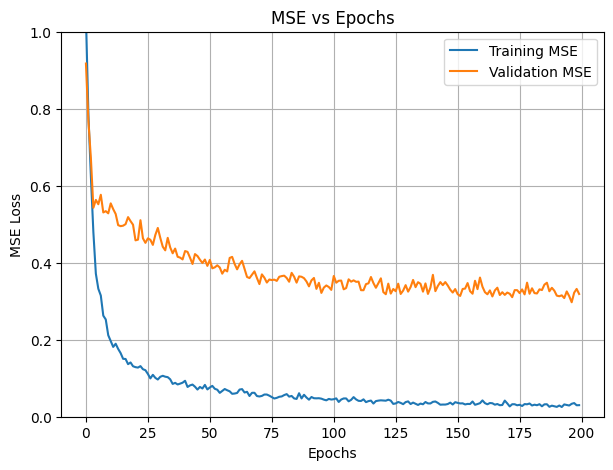

In [223]:
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label='Training MSE')
plt.plot(history.history['val_loss'], label='Validation MSE')
plt.ylim(0, 1)
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.title('MSE vs Epochs')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
train_loss, train_r2, train_mape = model1.evaluate(X_train_scaled, y_train_scaled, verbose=0)

test_loss, test_r2, test_mape = model1.evaluate(X_test_scaled, y_test_scaled, verbose=0)

print("Training MSE:", train_loss)
print("Training R2-score:", train_r2)
print("Training MAPE:", train_mape)

print("Testing MSE:", test_loss)
print("Testing R2-score:", test_r2)
print("Testing MAPE:", test_mape)


Training MSE: 0.07251006364822388
Training R2-score: 0.9307536482810974
Training MAPE: 78.27589416503906
Testing MSE: 0.21578258275985718
Testing R2-score: 0.729674756526947
Testing MAPE: 148.07366943359375


In [225]:
y_train_pred_scaled = model1.predict(X_train_scaled)
y_test_pred_scaled = model1.predict(X_test_scaled)

# Convert predictions back to original stress scale
y_train_pred = y_train_pred_scaled * y_std + y_mean
y_test_pred = y_test_pred_scaled * y_std + y_mean


125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [226]:
train_mse_actual = np.mean((y_train - y_train_pred)**2)
test_mse_actual = np.mean((y_test - y_test_pred)**2)


print("Training MSE in actual stress scale:", train_mse_actual)
print("Testing MSE in actual stress scale:", test_mse_actual)

# Additional simple testing metrics

# Mean Absolute Percentage Error
mape = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

# R2 score
ss_res = np.sum((y_test - y_test_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2 = 1 - (ss_res / ss_tot)

print("Testing MAPE (%):", mape)
print("Testing R2 Score:", r2)



Training MSE in actual stress scale: 1178887527307.832
Testing MSE in actual stress scale: 3508249405773.172
Testing MAPE (%): 10.17698296262993
Testing R2 Score: 0.7361932518514627


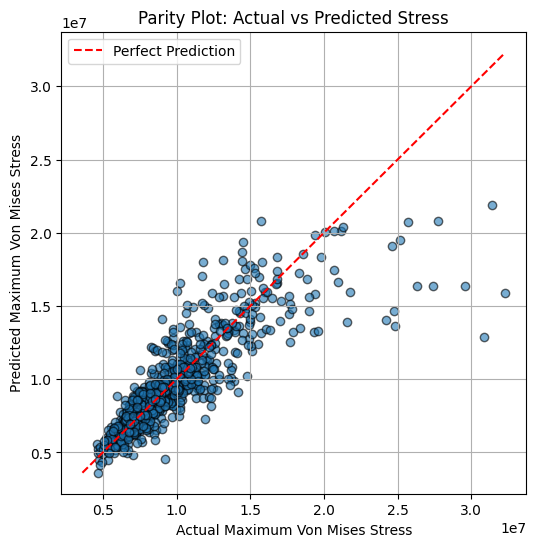

In [227]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolor="black")

min_val = min(np.min(y_test), np.min(y_test_pred))
max_val = max(np.max(y_test), np.max(y_test_pred))

plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Prediction")

plt.xlabel("Actual Maximum Von Mises Stress")
plt.ylabel("Predicted Maximum Von Mises Stress")
plt.title("Parity Plot: Actual vs Predicted Stress")
plt.legend()
plt.grid(True)
plt.show()


In [228]:
# Pick one random sample from the test set
random_index = np.random.randint(0, X_test.shape[0])

given_distribution = X_test[random_index].reshape(1, -1)
actual_stress = y_test[random_index]

# Scale input using training mean and std
given_distribution_scaled = (given_distribution - X_mean) / X_std

# Predict scaled output
predicted_stress_scaled = model1.predict(given_distribution_scaled)

# Convert prediction back to actual stress scale
predicted_stress = predicted_stress_scaled * y_std + y_mean

print("Random test sample number:", random_index)
print("Actual maximum Von Mises stress:", actual_stress[0])
print("Predicted maximum Von Mises stress:", predicted_stress[0][0])
print("Absolute error:", abs(actual_stress[0] - predicted_stress[0][0]))
print("Percentage error:", abs(actual_stress[0] - predicted_stress[0][0]) / actual_stress[0] * 100)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Random test sample number: 62
Actual maximum Von Mises stress: 9022466.62044744
Predicted maximum Von Mises stress: 9656947.949560605
Absolute error: 634481.3291131649
Percentage error: 7.032238032061568
